# Netflix Data Analysis

**Dataset:** `netflix_titles.csv` — 8,807 titles (Movies & TV Shows)  
**Goal:** Basic Exploratory Data Analysis (EDA) of the Netflix catalog.

---

## Table of Contents
1. [Import Libraries](#1)
2. [Load Dataset](#2)
3. [Inspect the Data](#3)
4. [Missing Values](#4)
5. [Clean & Prepare](#5)
6. [Basic EDA](#6)


---
<a id="1"></a>
## 1. Import Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
<a id="2"></a>
## 2. Load Dataset

In [46]:
df = pd.read_csv("netflix_titles.csv")

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset loaded: 8,807 rows x 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


---
<a id="3"></a>
## 3. Inspect the Data

In [47]:
# Shape & Column Names
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())

Shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [48]:
# Data Types and Non-null Counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [49]:
# Statistical Summary
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


---
<a id="4"></a>
## 4. Missing Values

In [50]:
# Missing Value Report
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %"    : missing_pct
}).sort_values("Missing Count", ascending=False)

print('Missing Value Summary:\n')
print(missing_df[missing_df["Missing Count"] > 0].to_string())

Missing Value Summary:

            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


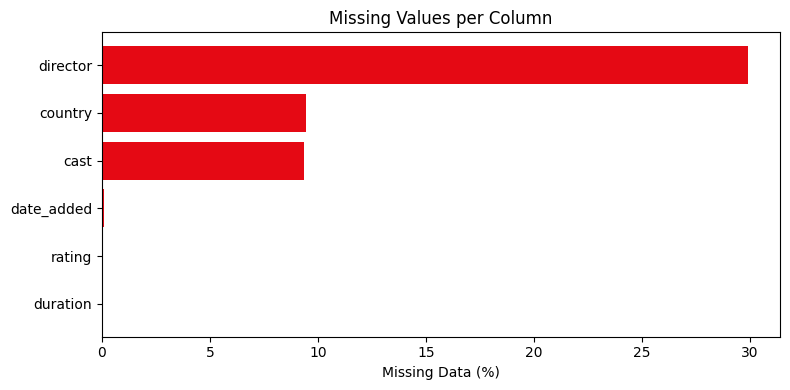

In [51]:
# Visualize Missing Values
cols_with_missing = missing_df[missing_df["Missing Count"] > 0].index.tolist()
vals = missing_df.loc[cols_with_missing, "Missing %"]

plt.figure(figsize=(8, 4))
plt.barh(cols_with_missing, vals, color="#E50914")
plt.xlabel("Missing Data (%)")
plt.title("Missing Values per Column")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [52]:
# Duplicate Check
n_dups = df.duplicated().sum()
print(f'Total duplicate rows  : {n_dups}')
print(f'Total rows            : {len(df)}')

n_dups_no_id = df.drop(columns="show_id").duplicated().sum()
print(f'Duplicates (excl. show_id): {n_dups_no_id}')

Total duplicate rows  : 0
Total rows            : 8807
Duplicates (excl. show_id): 0


---
<a id="5"></a>
## 5. Clean & Prepare

In [53]:
# Fill missing values
df_clean = df.copy()

df_clean["director"]   = df_clean["director"].fillna("Unknown")
df_clean["cast"]       = df_clean["cast"].fillna("Unknown")
df_clean["country"]   = df_clean["country"].fillna("Unknown")
df_clean["date_added"] = df_clean["date_added"].fillna("Unknown")
df_clean["rating"]    = df_clean["rating"].fillna(df_clean["rating"].mode()[0])
df_clean.dropna(subset=["duration"], inplace=True)
df_clean.reset_index(drop=True, inplace=True)

print('Cleaning complete!')
print(f'Rows remaining: {len(df_clean):,}')
print(f'\nRemaining nulls:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}')

Cleaning complete!
Rows remaining: 8,804

Remaining nulls:
Series([], dtype: int64)


In [54]:
# Feature Engineering
df_clean["date_added"] = df_clean["date_added"].str.strip()
df_clean["date_added_parsed"] = pd.to_datetime(df_clean["date_added"], format="%B %d, %Y", errors="coerce")
df_clean["year_added"]  = df_clean["date_added_parsed"].dt.year
df_clean["month_added"] = df_clean["date_added_parsed"].dt.month

df_clean["duration_int"] = df_clean["duration"].str.extract(r"(\d+)").astype(float)
df_clean["primary_country"] = df_clean["country"].str.split(",").str[0].str.strip()
df_clean["primary_genre"]   = df_clean["listed_in"].str.split(",").str[0].str.strip()

print('Feature engineering complete!')
df_clean[["title", "type", "year_added", "month_added", "duration_int", "primary_country", "primary_genre"]].head()

Feature engineering complete!


,title,type,year_added,month_added,duration_int,primary_country,primary_genre
0,Dick Johnson Is Dead,Movie,2021.0,9.0,90.0,United States,Documentaries
1,Blood & Water,TV Show,2021.0,9.0,2.0,South Africa,International TV Shows
2,Ganglands,TV Show,2021.0,9.0,1.0,Unknown,Crime TV Shows
3,Jailbirds New Orleans,TV Show,2021.0,9.0,1.0,Unknown,Docuseries
4,Kota Factory,TV Show,2021.0,9.0,2.0,India,International TV Shows


---
<a id="6"></a>
## 6. Basic EDA

In [55]:
# Content Type Distribution
type_counts = df_clean["type"].value_counts()
print('Content Type Distribution:')
print(type_counts)

Content Type Distribution:
type
Movie      6128
TV Show    2676
Name: count, dtype: int64


In [56]:
# Ratings Distribution
print('Rating Distribution:')
print(df_clean["rating"].value_counts())

Rating Distribution:
rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [57]:
# Release Year Summary
print(f'Oldest release year : {df_clean["release_year"].min()}')
print(f'Newest release year : {df_clean["release_year"].max()}')
print('\nTop 5 release years:')
print(df_clean["release_year"].value_counts().head())

Oldest release year : 1925
Newest release year : 2021

Top 5 release years:
release_year
2018    1147
2017    1031
2019    1030
2020     953
2016     902
Name: count, dtype: int64


In [58]:
# Top 10 Countries
print('Top 10 Countries:')
print(df_clean[df_clean["primary_country"] != "Unknown"]["primary_country"].value_counts().head(10))

Top 10 Countries:
primary_country
United States     3208
India             1008
United Kingdom     628
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico             134
Australia          117
Name: count, dtype: int64


In [59]:
# Top 10 Genres
print('Top 10 Genres:')
print(df_clean["primary_genre"].value_counts().head(10))

Top 10 Genres:
primary_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       774
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     388
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64


---
### Visualizations

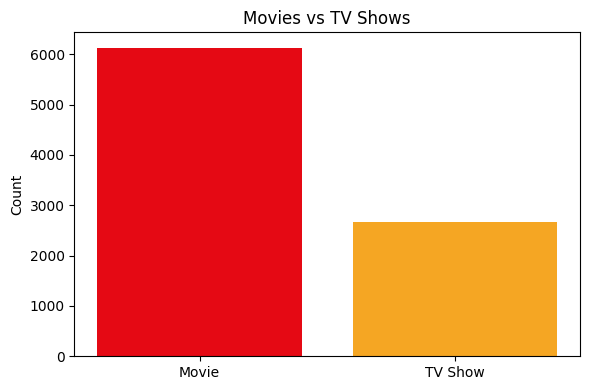

In [60]:
# Plot 1: Movies vs TV Shows
type_counts = df_clean["type"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(type_counts.index, type_counts.values, color=["#E50914", "#F5A623"])
plt.title("Movies vs TV Shows")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

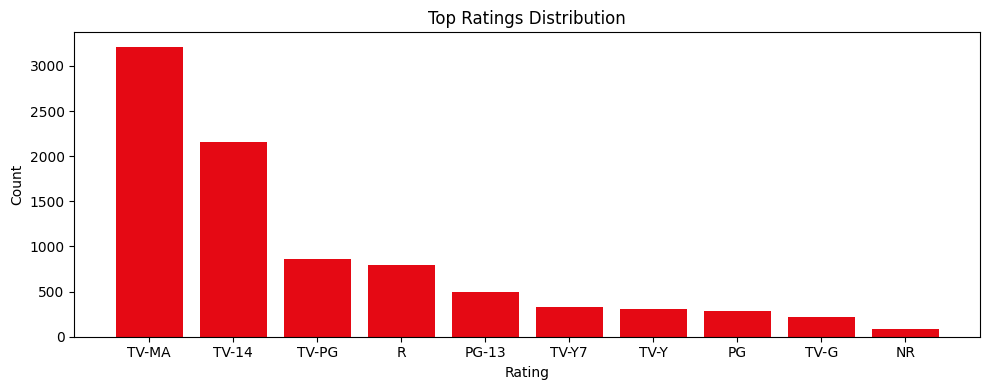

In [61]:
# Plot 2: Rating Distribution
top_ratings = df_clean["rating"].value_counts().head(10)
plt.figure(figsize=(10, 4))
plt.bar(top_ratings.index, top_ratings.values, color="#E50914")
plt.title("Top Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

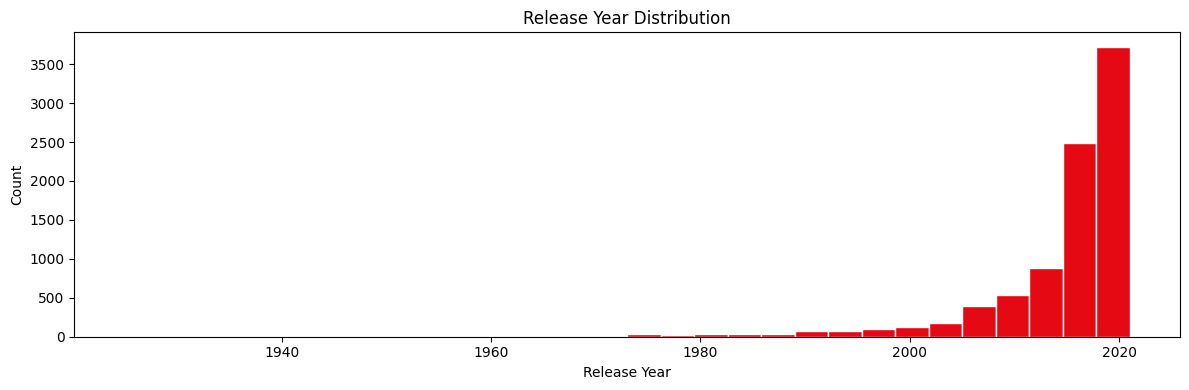

In [62]:
# Plot 3: Release Year Distribution
plt.figure(figsize=(12, 4))
plt.hist(df_clean["release_year"], bins=30, color="#E50914", edgecolor="white")
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

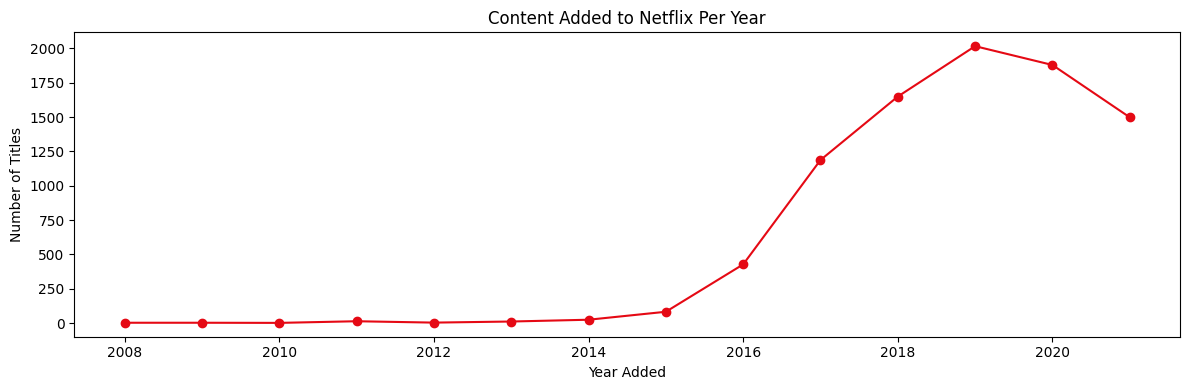

In [63]:
# Plot 4: Content Added Per Year
yearly = df_clean.dropna(subset=["year_added"])["year_added"].value_counts().sort_index()
plt.figure(figsize=(12, 4))
plt.plot(yearly.index, yearly.values, marker="o", color="#E50914")
plt.title("Content Added to Netflix Per Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

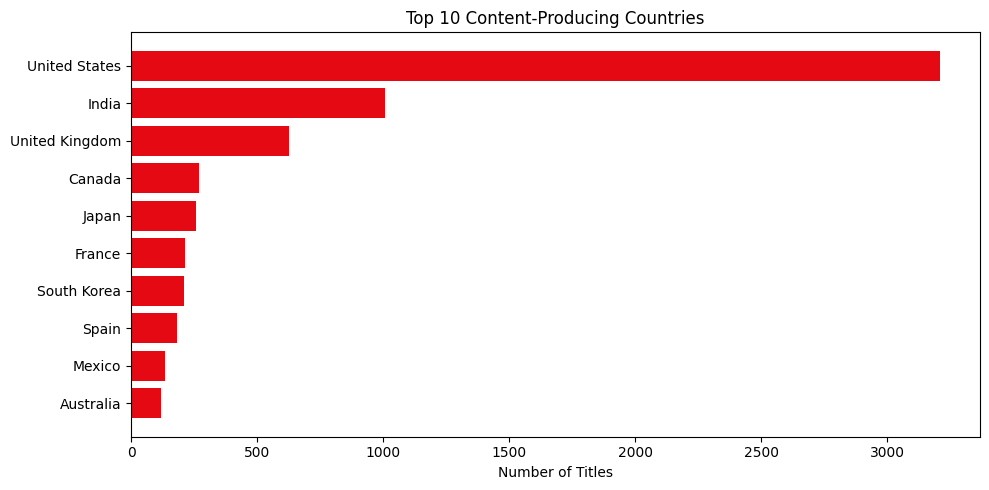

In [64]:
# Plot 5: Top 10 Countries
top_countries = df_clean[df_clean["primary_country"] != "Unknown"]["primary_country"].value_counts().head(10)
plt.figure(figsize=(10, 5))
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color="#E50914")
plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.show()

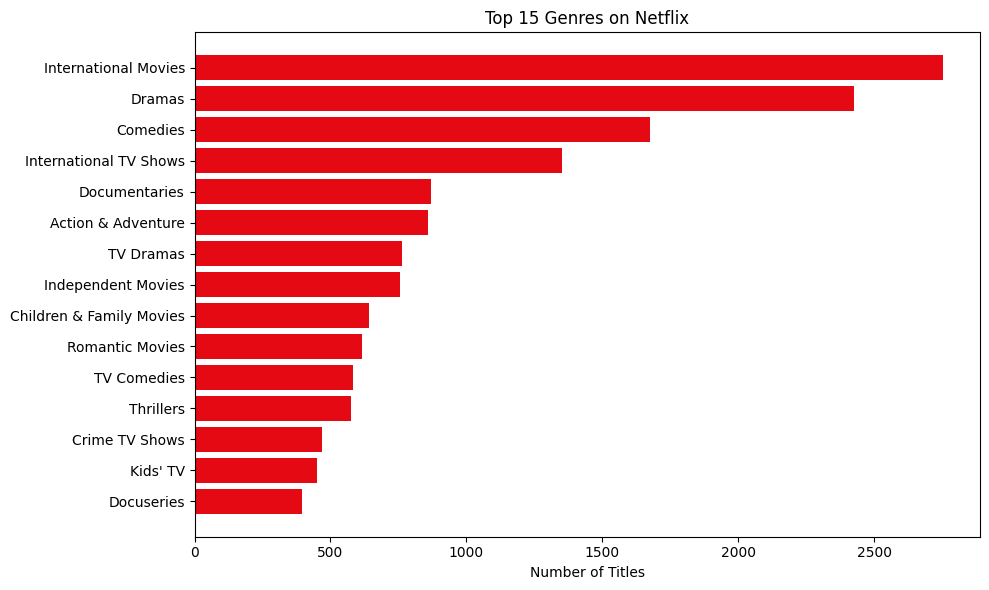

In [65]:
# Plot 6: Top 15 Genres
all_genres = df_clean["listed_in"].str.split(", ").explode().value_counts().head(15)
plt.figure(figsize=(10, 6))
plt.barh(all_genres.index[::-1], all_genres.values[::-1], color="#E50914")
plt.title("Top 15 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.show()

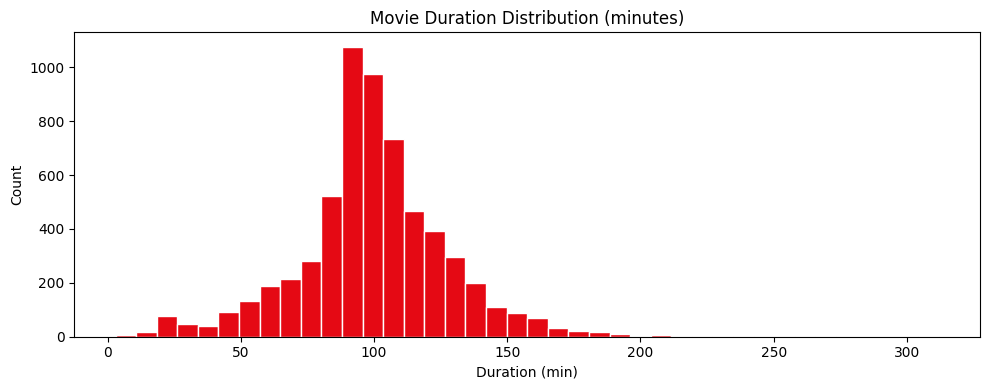

In [66]:
# Plot 7: Movie Duration Distribution
movies = df_clean[df_clean["type"] == "Movie"]
plt.figure(figsize=(10, 4))
plt.hist(movies["duration_int"].dropna(), bins=40, color="#E50914", edgecolor="white")
plt.title("Movie Duration Distribution (minutes)")
plt.xlabel("Duration (min)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()